# Text Extraction with LLMs

## What is text extraction?

Text extraction is the process of recognizing and extracting any written information on an image. Optical character recognition (OCR), handwritten text recognition (HTR) a

[add image here to show what is happening]




### Brief historical pivot

USPS

## Historical text recognition?

### Print

ABBYY FineReader 
Adobe


### Handwritten

transkribus
trocr

language specific models vs corpus specific models vs more general

## Why LLMs?

One of the biggest advantages of using a multimodal large language model like Gemini for text extraction, compared to OCR software, is that these models allow us to modify the extraction process.

The output of OCR software is often a txt file. OCR software does not retain information about whether a line was bold or in a larger font. It turns everything into plain text. While there are ways to retain this type of information, like extracting text into HTML, this is not always reliable. In the next notebook we will explore this in more detail by using Adobe and ABBYY FineReader as a comparative example.

### Adobe

To briefly illustrate, the code below shows page 29 from the 1764 French edition of Lady Montagu's letters and the OCR'd version of that same page. The OCR'd version was already in the PDF, embedded as a text layer. This is not the case for all PDFs, as some are just images without text layers. This one happens to be OCR'd with the output retained as the text layer. pypdf's extract_text() function would return an empty string if there wasn't a text layer in the PDF already.

![img](adobe.png)

In [7]:
import os
import matplotlib.pyplot as plt
from pdf2image import convert_from_path
from pypdf import PdfReader

In [ ]:
# File location
page_file = "few_shot_examples/page_29.pdf"

# Convert PDF to image
images = convert_from_path(page_file)
page_image = images[0]

# Extract embedded OCR text layer from the PDF
reader = PdfReader(page_file)
ocr_text = reader.pages[0].extract_text()

# Display side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Left: PDF image
axes[0].imshow(page_image)
axes[0].set_title('Page 29 - PDF Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Right: OCR text
axes[1].text(0.05, 0.95, ocr_text, transform=axes[1].transAxes, 
             fontsize=10, verticalalignment='top', fontfamily='monospace',
             wrap=True)
axes[1].set_title('Embedded OCR Text Layer', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### ABBYY FineReader

More complex, train our own model etc

![img](abbyy.png)

the page layout etc would allow us to do more sofisticated stuff and we can also download these pages as HTML and try to work with the font data preserved there

In [1]:
from IPython.display import display, HTML, Code
from bs4 import BeautifulSoup
import html

In [2]:
with open("abbyy_page29.htm") as f:
    content = f.read()

fixed = content.replace('<body>', '<body style="background:white !important; color:black !important;">')
display(HTML(fixed))


□ igitizedby GoOgle,Original from NEW YORK PUBLIC LIBRARY


In [3]:
from pygments import highlight
from pygments.lexers import HtmlLexer
from pygments.formatters import HtmlFormatter

formatter = HtmlFormatter(style="monokai", noclasses=True)

with open("abbyy_page29.htm") as f:
    content = f.read()

pretty = BeautifulSoup(content, "html.parser").prettify()

highlighted = highlight(pretty, HtmlLexer(), formatter)
display(HTML(highlighted))


In [ ]:
# finally let's look at the text output

with open("abbyy_page29.txt") as f:
    content = f.read()

escaped = html.escape(content)
display(HTML(f'<pre style="white-space: pre-wrap; word-wrap: break-word; font-family: monospace; background: #1e1e1e; color: #d4d4d4; padding: 10px; border-radius: 5px;">{escaped}</pre>'))



### Issues

Using the text output alone does not help us sufficiently differentiate between different parts of the text

relying on html to get different parts of the text is an uphill battle, considering that some words were randomly assinged bold fonts

in both cases, lots of text recognition errors

### Solutions

Sure, we can train our own model. ABBYY is one of the best options for printed materials and you don't have to split it into lines, you work on page level

Or we can experiment with LLMs :D



## Structured Text Extraction

### What is the ideal output that we want?

Let's take a closer look at a couple of pages to gain a deeper understanding of the structure of our text.

In [5]:
pages_folder = "few_shot_examples"
example_pages = ['page_16.pdf', 'page_17.pdf', 'page_22.pdf', 'page_24.pdf', 'page_29.pdf', 'page_31.pdf']

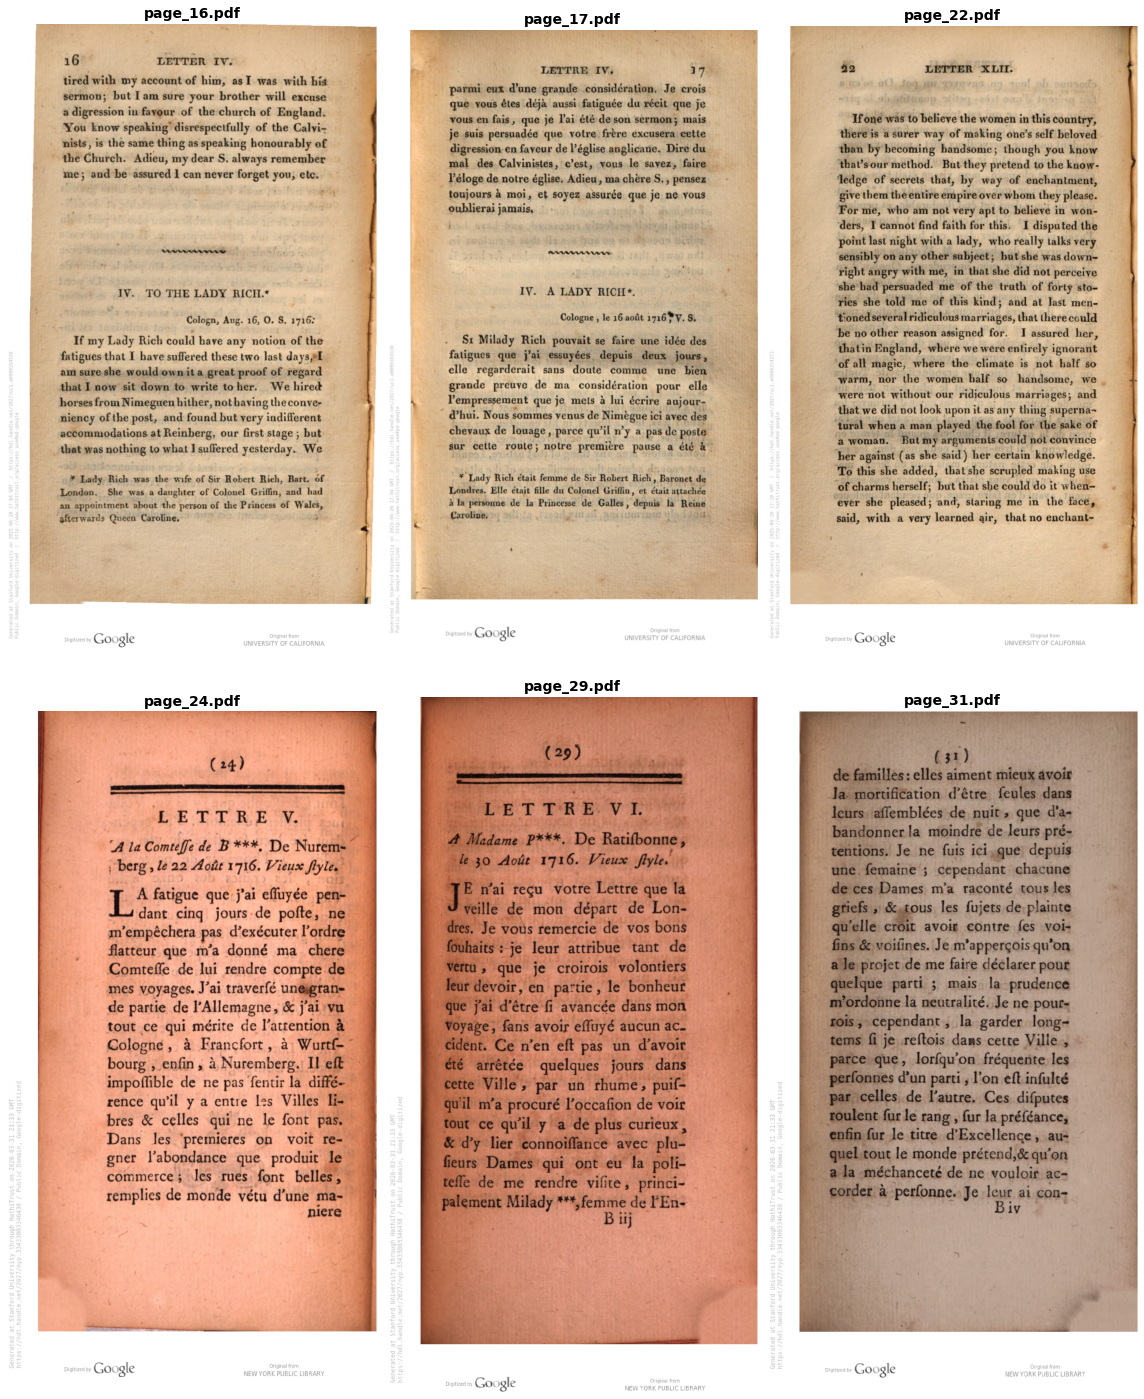

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 20))
axes = axes.flatten()

for idx, page_file in enumerate(example_pages):
    page_path = os.path.join(pages_folder, page_file)
    
    # Convert PDF to image
    images = convert_from_path(page_path)
    page_image = images[0]
    
    # Display
    axes[idx].imshow(page_image)
    axes[idx].set_title(f'{page_file}', fontsize=14, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

some information about different layout like beginning of letter, mid letter, end of letter, languages

### JSON

We will turn them into JSON

Why? some notes about how json came to be the main way to get structured data out of llms

Here is what page 29 looks like in the structure that we want it to be

```json
{
  "page": 29,
  "language": "fr",
  "letters": [
    {
      "number": "VI",
      "heading": "LETTRE VI.",
      "recipient": "A Madame P***.",
      "location": "Ratisbonne",
      "date": "le 30 Août 1716. Vieux style.",
      "body": "JE n'ai reçu votre Lettre que la veille de mon départ de Londres. Je vous remercie de vos bons souhaits : je leur attribue tant de vertu, que je croirois volontiers leur devoir, en partie, le bonheur que j'ai d'être si avancée dans mon voyage, sans avoir essuyé aucun accident. Ce n'en est pas un d'avoir été arrêtée quelques jours dans cette Ville, par un rhume, puisqu'il m'a procuré l'occasion de voir tout ce qu'il y a de plus curieux, & d'y lier connoissance avec plusieurs Dames qui ont eu la politesse de me rendre visite, principalement Milady ***, femme de l'En-",
      "footnote": null
    }
  ]
}
```


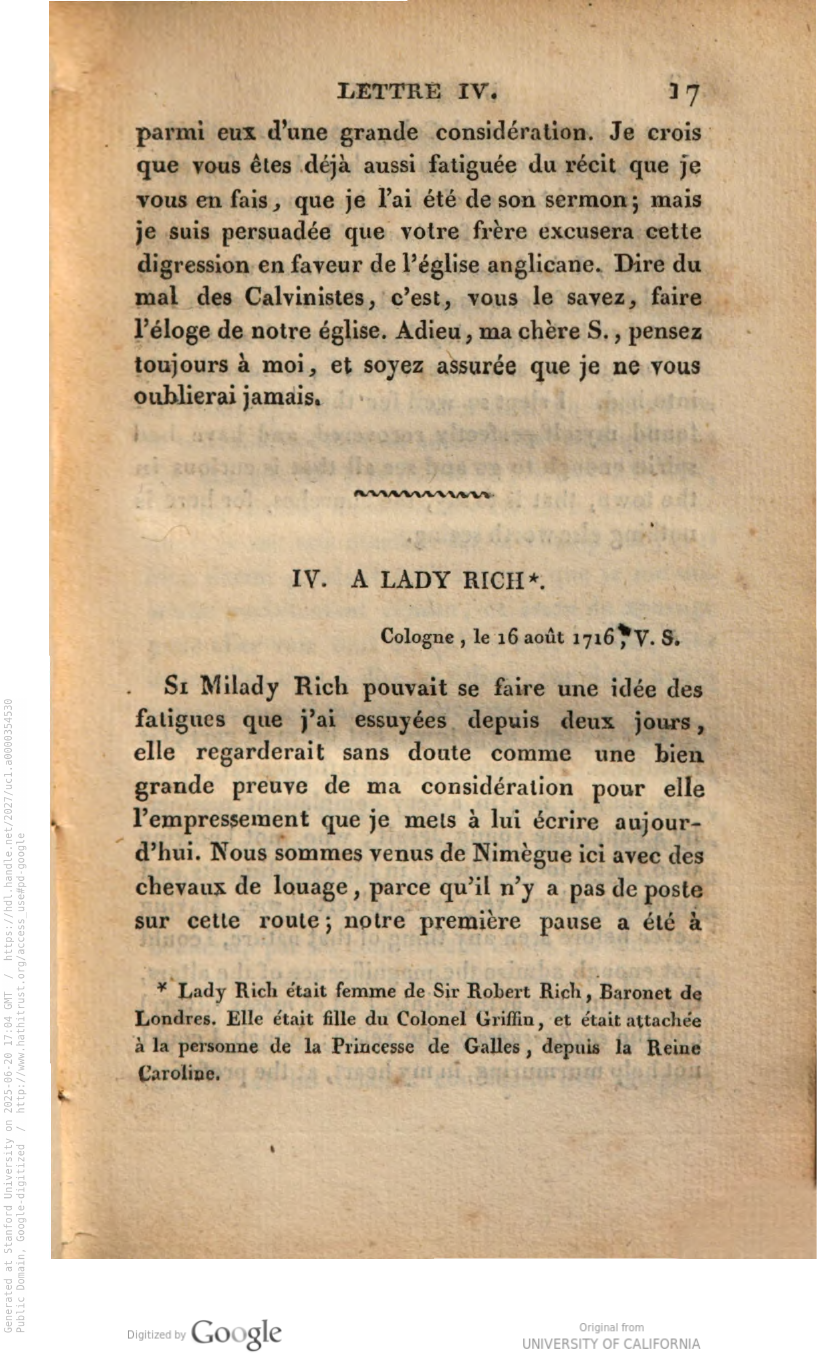

In [13]:
import json, base64, html as html_module, io
from pdf2image import convert_from_path

# Convert PDF to image
page_image = convert_from_path("few_shot_examples/page_17.pdf")[0]
buf = io.BytesIO()
page_image.save(buf, format="PNG")
img_data = base64.b64encode(buf.getvalue()).decode()

# Read and format JSON
with open("few_shot_examples/page_17.json") as f:
    json_content = json.dumps(json.load(f), indent=2, ensure_ascii=False)

display(HTML(f'''
<div style="display:flex; gap:20px; align-items:flex-start;">
  <div style="flex:1;">
    <img src="data:image/png;base64,{img_data}" style="max-width:100%; height:auto;">
  </div>
  <div style="flex:1; overflow:auto; max-height:500px; background:white; color:black;">
    <pre style="white-space:pre-wrap; word-wrap:break-word; margin:0;">{html_module.escape(json_content)}</pre>
  </div>
</div>
'''))
